In [138]:
from pathlib import Path
import pandas as pd
import tarfile
import urllib.request

def load_information():
    tarball_path = Path("datasets/housing.tgz")
    if not tarball_path.is_file():
        Path("datasets").mkdir(parents=True, exist_ok=True)
        url = "https://github.com/ageron/data/raw/main/housing.tgz"
        urllib.request.urlretrieve(url, tarball_path)
        with tarfile.open(tarball_path) as housing_tarball:
            housing_tarball.extractall(path="datasets", filter="data")
    return pd.read_csv(Path("datasets/housing/housing.csv"))

housing_data = load_information()

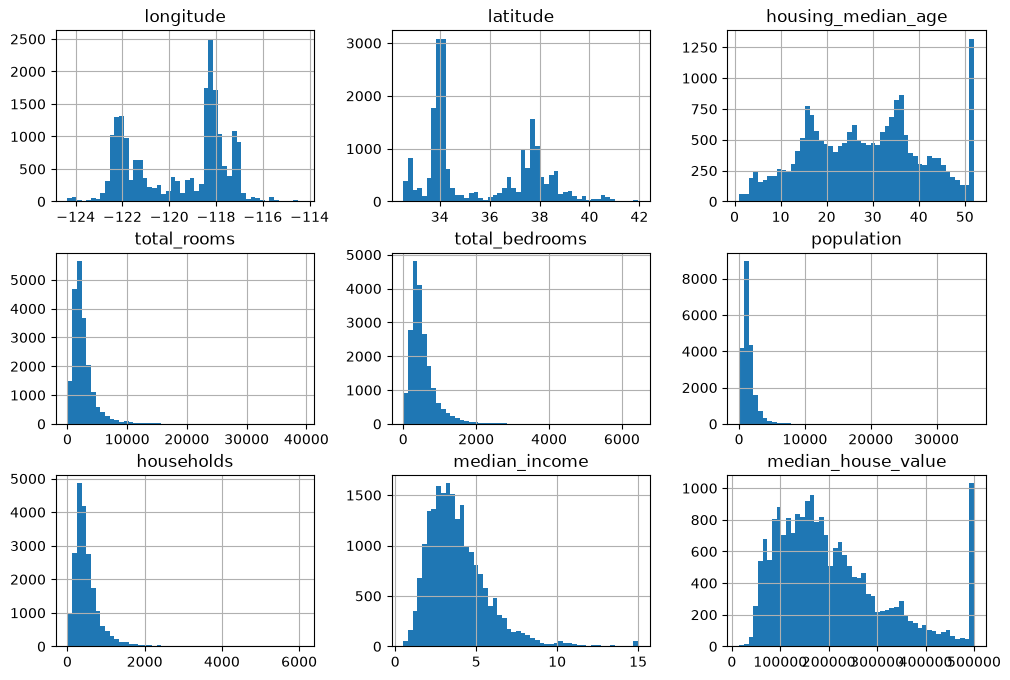

In [139]:
import matplotlib.pyplot as plt

#visualize data
housing_data.hist(bins=50, figsize=(12, 8))
plt.show()

In [140]:
import numpy as np

#1st way to split the data
def shuffle_and_split_data(data, test_ratio, rng):
    shuffled_indices = rng.permutation(len(data))
    test_set_size = int(len(data)*test_ratio)
    test_indices = shuffled_indices[:test_set_size]
    train_indices = shuffled_indices[test_set_size:]
    return data.iloc[train_indices], data.iloc[test_indices]

In [141]:
#spliting test
rng = np.random.default_rng()
train_set, test_set = shuffle_and_split_data(housing_data, 0.2, rng)
print(train_set.head(3))
print(test_set.head(3))

       longitude  latitude  ...  median_house_value  ocean_proximity
11984    -119.66     36.33  ...             92800.0           INLAND
5643     -118.67     34.28  ...            235300.0        <1H OCEAN
2709     -119.10     35.35  ...            131000.0           INLAND

[3 rows x 10 columns]
       longitude  latitude  ...  median_house_value  ocean_proximity
1342     -118.98     35.37  ...             47100.0           INLAND
19684    -122.26     37.46  ...            500001.0       NEAR OCEAN
19616    -119.82     36.77  ...             65600.0           INLAND

[3 rows x 10 columns]


In [142]:
from zlib import crc32

#2nd way to split the data
def is_id_in_testset(identifier, test_ratio):
    return crc32(np.int64(identifier)) < test_ratio * 2**32

def split_data_with_id_hash(data, test_ratio, id_column):
    ids = data[id_column]
    in_test_dataset = ids.apply(lambda id_: is_id_in_testset(id_, test_ratio))
    return data[~in_test_dataset], data[in_test_dataset]

In [143]:
#spliting test
housing_with_id = housing_data.reset_index()
train_set, test_set = split_data_with_id_hash(housing_with_id, 0.2, "index")
print(train_set.head(3))
print(test_set.head(3))

   index  longitude  ...  median_house_value  ocean_proximity
0      0    -122.23  ...            452600.0         NEAR BAY
1      1    -122.22  ...            358500.0         NEAR BAY
3      3    -122.25  ...            341300.0         NEAR BAY

[3 rows x 11 columns]
    index  longitude  ...  median_house_value  ocean_proximity
2       2    -122.24  ...            352100.0         NEAR BAY
5       5    -122.25  ...            269700.0         NEAR BAY
12     12    -122.26  ...            213500.0         NEAR BAY

[3 rows x 11 columns]


In [144]:
#spliting by unique omen and generating values via crc32(longitude and latitude)
housing_with_id["id"] = (housing_with_id["longitude"]*1000 + housing_with_id["latitude"])
train_set, test_set = split_data_with_id_hash(housing_with_id, 0.2, "id")
print(train_set.head(3))

   index  longitude  latitude  ...  median_house_value  ocean_proximity         id
0      0    -122.23     37.88  ...            452600.0         NEAR BAY -122192.12
1      1    -122.22     37.86  ...            358500.0         NEAR BAY -122182.14
2      2    -122.24     37.85  ...            352100.0         NEAR BAY -122202.15

[3 rows x 12 columns]


In [145]:
from sklearn.model_selection import train_test_split

#3rd way using sklearn.model_selection.train_test_split
train_set, test_set = train_test_split(housing_data, test_size=0.2, random_state=42)
print(train_set.head(3))
print(test_set.head(3))

       longitude  latitude  ...  median_house_value  ocean_proximity
14196    -117.22     32.75  ...            291000.0       NEAR OCEAN
8267     -117.03     32.69  ...            156100.0       NEAR OCEAN
17445    -122.27     37.74  ...            353900.0         NEAR BAY

[3 rows x 10 columns]
       longitude  latitude  ...  median_house_value  ocean_proximity
20046    -122.38     40.67  ...             65600.0           INLAND
3024     -118.37     33.83  ...            353400.0        <1H OCEAN
15663    -117.24     32.72  ...            466700.0       NEAR OCEAN

[3 rows x 10 columns]


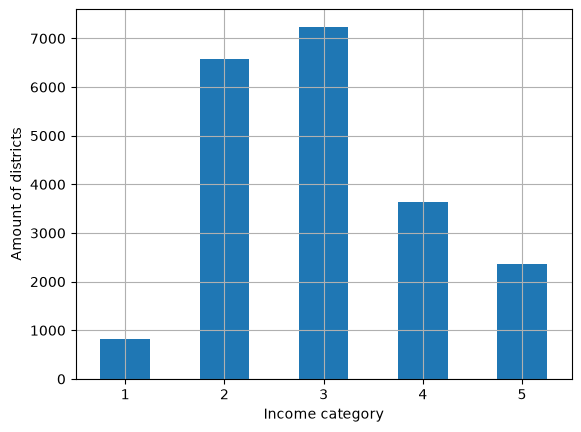

In [146]:
housing_data["income_cat"] = pd.cut(housing_data["median_income"], bins=[0., 1.5, 3., 4.5, 6., np.inf], labels=[1, 2, 3 , 4, 5])

cat_counts = housing_data["income_cat"].value_counts().sort_index()
cat_counts.plot.bar(rot=0, grid=True)
plt.ylabel("Amount of districts")
plt.xlabel("Income category")
plt.show()

In [147]:
from sklearn.model_selection import StratifiedShuffleSplit

splitter = StratifiedShuffleSplit(n_splits=10, test_size=0.2, random_state=42)

#implement stratifiedSplit for 
strat_splits = []
for train_indices, test_indices in splitter.split(X=housing_data, y=housing_data["income_cat"]):
    strat_train_set_n = housing_data.iloc[train_indices]
    strat_test_set_n = housing_data.iloc[test_indices]
    strat_splits.append([strat_train_set_n, strat_test_set_n])

In [148]:
strat_train_set, strat_test_set = strat_splits[0]
print(strat_train_set.head(3))
print(strat_test_set.head(3))

       longitude  latitude  ...  ocean_proximity  income_cat
13096    -122.42     37.80  ...         NEAR BAY           2
14973    -118.38     34.14  ...        <1H OCEAN           5
3785     -121.98     38.36  ...           INLAND           2

[3 rows x 11 columns]
       longitude  latitude  ...  ocean_proximity  income_cat
3905     -121.95     37.11  ...        <1H OCEAN           5
16821    -118.01     33.89  ...        <1H OCEAN           4
2900     -118.18     33.74  ...       NEAR OCEAN           3

[3 rows x 11 columns]


In [149]:
strat_train_set, strat_test_set = train_test_split(housing_data, test_size=0.2, stratify=housing_data["income_cat"], random_state=42)

In [150]:
print(strat_test_set["income_cat"].value_counts()/len(strat_test_set))
print(housing_data["income_cat"].value_counts()/len(housing_data))

income_cat
3    0.350533
2    0.318798
4    0.176357
5    0.114341
1    0.039971
Name: count, dtype: float64
income_cat
3    0.350581
2    0.318847
4    0.176308
5    0.114438
1    0.039826
Name: count, dtype: float64


In [151]:
for set_ in (strat_train_set, strat_test_set):
    set_.drop("income_cat", axis=1, inplace=True)

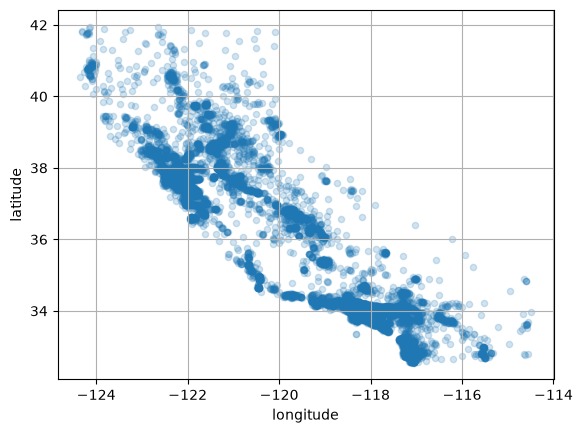

In [152]:
housing = strat_train_set.copy()

housing.plot(kind="scatter", x="longitude", y="latitude", grid=True, alpha=0.2)
plt.show()

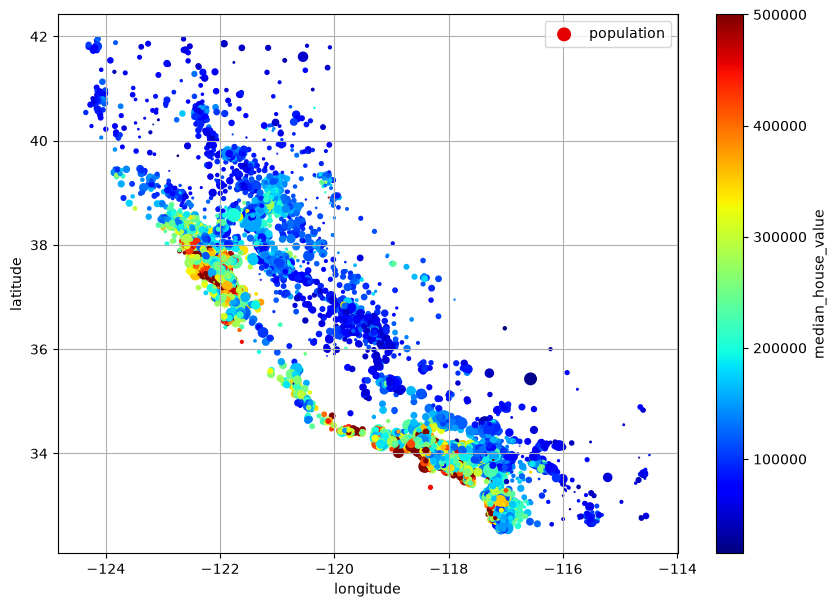

In [153]:
housing.plot(kind="scatter", x="longitude", y="latitude", grid=True, s=housing["population"]/100,
             label="population", c="median_house_value", cmap="jet", colorbar=True,
             legend=True, sharex=False, figsize=(10, 7))
plt.show()

In [154]:
corr_matrix = housing.corr(numeric_only=True)
print(corr_matrix["median_house_value"].sort_values(ascending=False))

median_house_value    1.000000
median_income         0.688380
total_rooms           0.137455
housing_median_age    0.102175
households            0.071426
total_bedrooms        0.054635
population           -0.020153
longitude            -0.050859
latitude             -0.139584
Name: median_house_value, dtype: float64


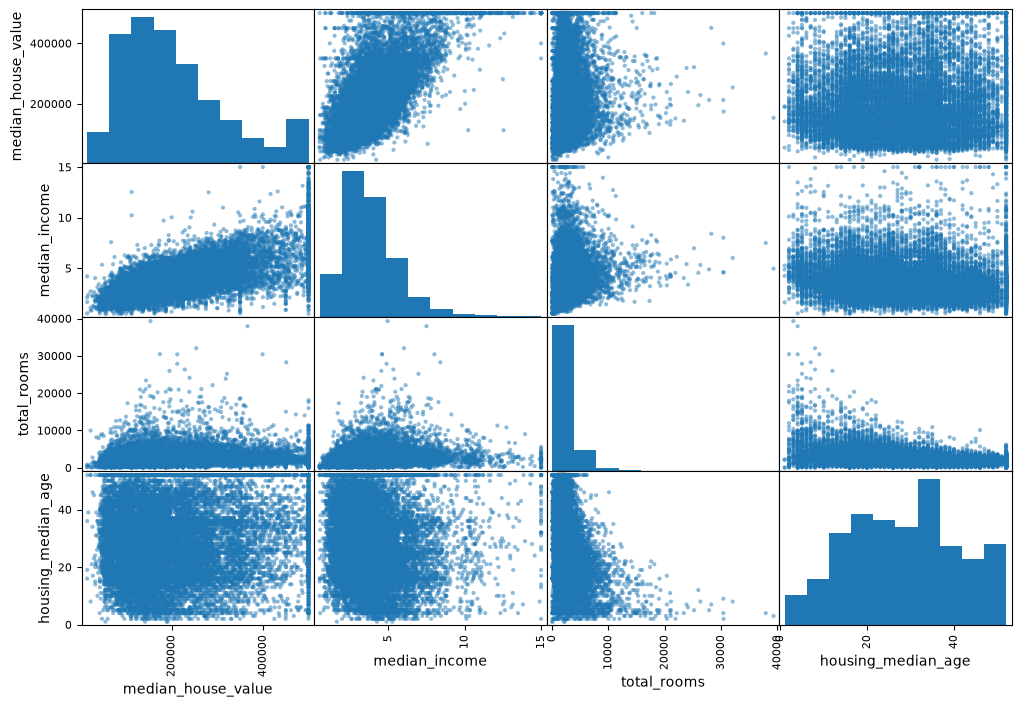

In [155]:
from pandas.plotting import scatter_matrix

attributes = ["median_house_value", "median_income", "total_rooms", "housing_median_age"]

scatter_matrix(housing[attributes], figsize=(12, 8))
plt.show()

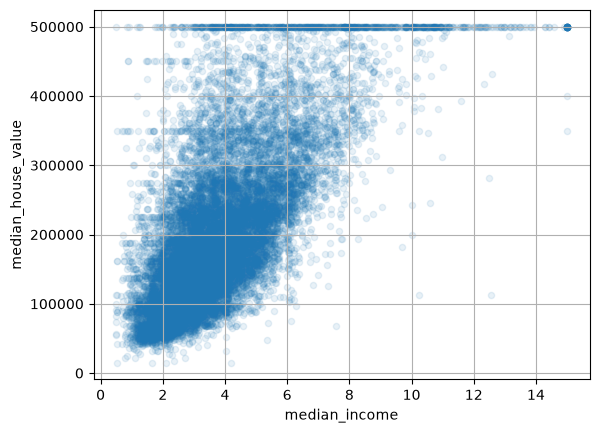

In [156]:
housing.plot(kind="scatter", x="median_income", y="median_house_value", alpha=0.1, grid=True)
plt.show()

In [157]:
housing["room_per_house"] = housing["total_rooms"]/housing["households"]
housing["bedrooms_ratio"] = housing["total_bedrooms"]/housing["total_rooms"]
housing["people_per_house"] = housing["population"]/housing["households"]

corr_matrix = housing.corr(numeric_only=True)
print(corr_matrix["median_house_value"].sort_values(ascending=False))

median_house_value    1.000000
median_income         0.688380
room_per_house        0.143663
total_rooms           0.137455
housing_median_age    0.102175
households            0.071426
total_bedrooms        0.054635
population           -0.020153
people_per_house     -0.038224
longitude            -0.050859
latitude             -0.139584
bedrooms_ratio       -0.256397
Name: median_house_value, dtype: float64


In [158]:
housing = strat_train_set.drop("median_house_value", axis=1)
housing_labels = strat_train_set["median_house_value"].copy()

In [159]:
# housing.dropna(subset=["total_bedrooms"], inplace=True) # option 1
# housing.drop("total_bedrooms", axis=1, inplace=True) # option 2

# median = housing["total_bedrooms"].median() # option 3
# housing["total_bedrooms"] = housing["total_bedrooms"].fillna(median)

In [160]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

housing_num = housing.select_dtypes(include=[np.number])
imputer.fit(housing_num)

print(imputer.statistics_) #or housing_num.median().values

[-118.51     34.26     29.     2125.      434.     1167.      408.
    3.5385]


In [161]:
X = imputer.transform(housing_num)
print(X)

[[-1.2242e+02  3.7800e+01  5.2000e+01 ...  1.5760e+03  1.0340e+03
   2.0987e+00]
 [-1.1838e+02  3.4140e+01  4.0000e+01 ...  6.6600e+02  3.5700e+02
   6.0876e+00]
 [-1.2198e+02  3.8360e+01  3.3000e+01 ...  5.6200e+02  2.0300e+02
   2.4330e+00]
 ...
 [-1.1706e+02  3.2590e+01  1.3000e+01 ...  2.8140e+03  7.6000e+02
   4.0616e+00]
 [-1.1840e+02  3.4060e+01  3.7000e+01 ...  1.7250e+03  8.3800e+02
   4.1455e+00]
 [-1.2241e+02  3.7660e+01  4.4000e+01 ...  6.8200e+02  2.1200e+02
   3.2833e+00]]


In [162]:
#rebuild the train dataset
housing_tr = pd.DataFrame(X, columns=housing_num.columns, index=housing_num.index)
print(housing_tr)

       longitude  latitude  ...  households  median_income
13096    -122.42     37.80  ...      1034.0         2.0987
14973    -118.38     34.14  ...       357.0         6.0876
3785     -121.98     38.36  ...       203.0         2.4330
14689    -117.11     33.75  ...       780.0         2.2618
20507    -118.15     33.77  ...      1172.0         3.5292
...          ...       ...  ...         ...            ...
14207    -118.40     33.86  ...       523.0         4.7105
13105    -119.31     36.32  ...       532.0         2.5733
19301    -117.06     32.59  ...       760.0         4.0616
19121    -118.40     34.06  ...       838.0         4.1455
19888    -122.41     37.66  ...       212.0         3.2833

[16512 rows x 8 columns]


In [163]:
housing_cat = housing[["ocean_proximity"]]
housing_cat.head(8)

,ocean_proximity
13096,NEAR BAY
14973,<1H OCEAN
3785,INLAND
14689,INLAND
20507,NEAR OCEAN
1286,INLAND
18078,<1H OCEAN
4396,NEAR BAY


In [164]:
from sklearn.preprocessing import OrdinalEncoder

ordinal_encoder = OrdinalEncoder()
housing_cat_encoded = ordinal_encoder.fit_transform(housing_cat)

housing_cat_encoded[:8]

array([[3.],
       [0.],
       [1.],
       [1.],
       [4.],
       [1.],
       [0.],
       [3.]])

In [165]:
from sklearn.preprocessing import OneHotEncoder

oneHot_encoder = OneHotEncoder(sparse_output=False) #encode dense NumPy arr. To encode sparse SciPy matrix delete the sparse_output=False
housing_cat1hot = oneHot_encoder.fit_transform(housing_cat)

print(housing_cat1hot)

[[0. 0. 0. 1. 0.]
 [1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 ...
 [0. 0. 0. 0. 1.]
 [1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1.]]


In [166]:
print(oneHot_encoder.categories_)

df_test = pd.DataFrame({"ocean_proximity": ["INLAND", "NEAR BAY"]})
print(pd.get_dummies(df_test))

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
      dtype=object)]
   ocean_proximity_INLAND  ocean_proximity_NEAR BAY
0                    True                     False
1                   False                      True


In [167]:
print(oneHot_encoder.transform(df_test))

[[0. 1. 0. 0. 0.]
 [0. 0. 0. 1. 0.]]


In [168]:
df_test_unknown = pd.DataFrame({"ocean_proximity": ["<2H OCEAN", "ISLAND"]})
print(pd.get_dummies(df_test_unknown))

   ocean_proximity_<2H OCEAN  ocean_proximity_ISLAND
0                       True                   False
1                      False                    True


In [169]:
oneHot_encoder.handle_unknown = "ignore"
print(oneHot_encoder.transform(df_test_unknown))

[[0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0.]]


In [ ]:
print(oneHot_encoder.feature_names_in_)
print('')
print(oneHot_encoder.get_feature_names_out())

['ocean_proximity']

['ocean_proximity_<1H OCEAN' 'ocean_proximity_INLAND'
 'ocean_proximity_ISLAND' 'ocean_proximity_NEAR BAY'
 'ocean_proximity_NEAR OCEAN']


In [ ]:
df_output = pd.DataFrame(oneHot_encoder.transform(df_test_unknown),
                         columns=oneHot_encoder.get_feature_names_out(),
                         index=df_test_unknown.index)
print(df_output)

   ocean_proximity_<1H OCEAN  ...  ocean_proximity_NEAR OCEAN
0                        0.0  ...                         0.0
1                        0.0  ...                         0.0

[2 rows x 5 columns]
